In [1]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline     
sns.set(color_codes=True)

In [2]:
df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')

C:\Users\Filip\AppData\Local\Temp\ipykernel_7360\3619123592.py:1: DtypeWarning: Columns (0: Vintage) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data\\XWines_Slim_150K_ratings.csv')


In [3]:
df.dtypes

RatingID      int64
UserID        int64
WineID        int64
Vintage      object
Rating      float64
Date            str
dtype: object

In [4]:
df.head(5)

,RatingID,UserID,WineID,Vintage,Rating,Date
0,143,1356810,103471,1950,4.5,2021-11-02 20:52:59
1,199,1173759,111415,1951,5.0,2015-08-20 17:46:26
2,348,1164877,111395,1952,5.0,2020-11-13 05:40:26
3,374,1207665,111433,1953,5.0,2017-05-05 06:44:13
4,834,1075841,111431,1955,5.0,2016-09-14 20:18:38


In [5]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 6)


In [6]:
df.count()

RatingID    150000
UserID      150000
WineID      150000
Vintage     150000
Rating      150000
Date        150000
dtype: int64

In [7]:
print(df.isnull().sum())

RatingID    0
UserID      0
WineID      0
Vintage     0
Rating      0
Date        0
dtype: int64


In [8]:
df["Rating"].describe()


count    150000.000000
mean          3.820030
std           0.650348
min           1.000000
25%           3.500000
50%           4.000000
75%           4.000000
max           5.000000
Name: Rating, dtype: float64

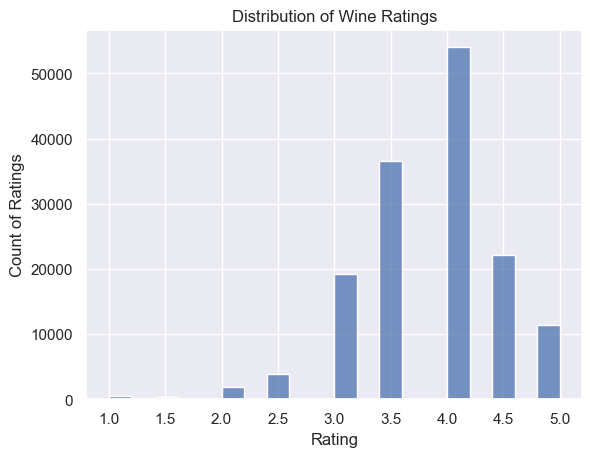

In [9]:

sns.histplot(df['Rating'], bins=20)  # ratingi od 1 do 5
plt.xlabel("Rating")
plt.ylabel("Count of Ratings")
plt.title("Distribution of Wine Ratings")
plt.show()


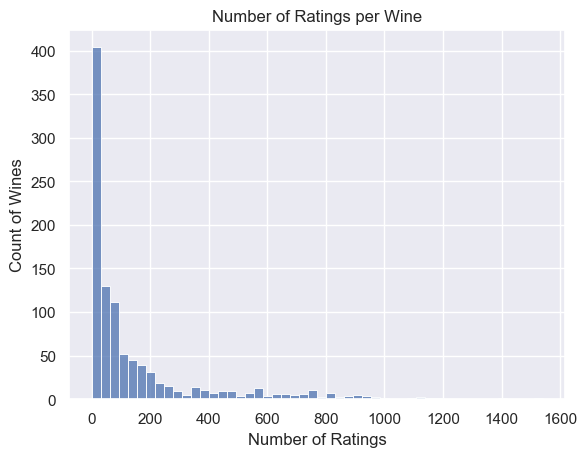

In [10]:

sns.histplot(df['WineID'].value_counts(), bins=50)
plt.xlabel("Number of Ratings")
plt.ylabel("Count of Wines")
plt.title("Number of Ratings per Wine")
plt.show()


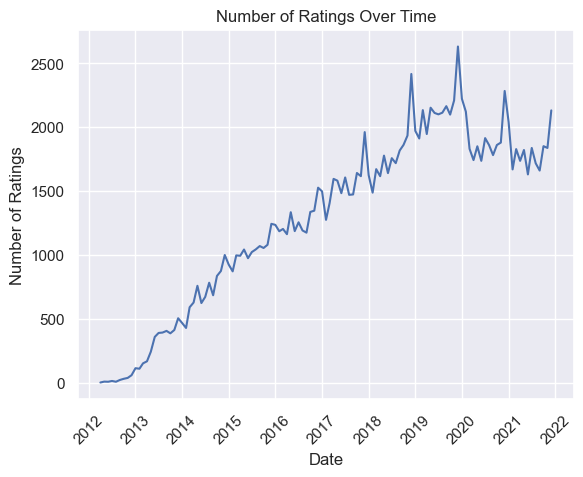

In [11]:
df['Date'] = pd.to_datetime(df['Date'])
ratings_over_time = df.groupby(df['Date'].dt.to_period('M')).size()  # liczba ocen w każdym miesiącu



sns.lineplot(x=ratings_over_time.index.to_timestamp(), y=ratings_over_time.values)
plt.xlabel("Date")
plt.ylabel("Number of Ratings")
plt.title("Number of Ratings Over Time")
plt.xticks(rotation=45)
plt.show()



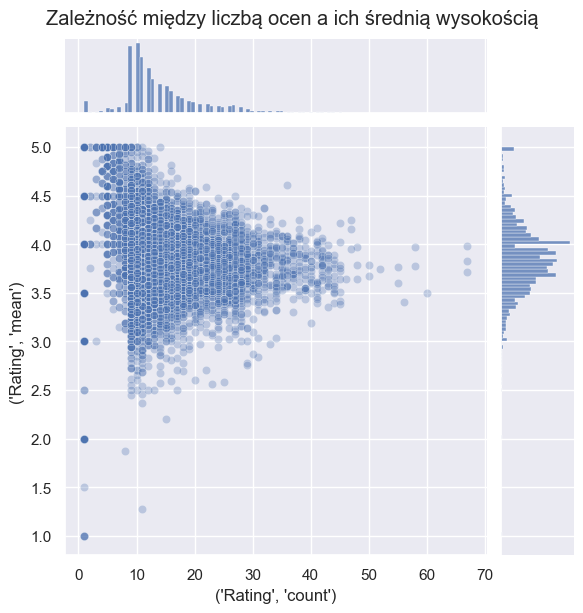

In [13]:
user_stats = df.groupby('UserID').agg({'Rating': ['count', 'mean']})
sns.jointplot(x=user_stats[('Rating', 'count')], y=user_stats[('Rating', 'mean')], alpha=0.3)
plt.suptitle("Zależność między liczbą ocen a ich średnią wysokością", y=1.02)
plt.show()

In [12]:
# --- COLD-START (braki w treningu) ---
# Załóżmy, że mamy X_train i X_test
train_users = set(X_train['UserID'])
train_wines = set(X_train['WineID'])
test_users = set(X_test['UserID'])
test_wines = set(X_test['WineID'])

new_users = test_users - train_users
new_wines = test_wines - train_wines

print(f"Nowi użytkownicy w teście (cold-start): {len(new_users)}")
print(f"Nowe wina w teście (cold-start): {len(new_wines)}")

cold_start_flags = X_test['UserID'].isin(new_users) | X_test['WineID'].isin(new_wines)
cold_start_counts = cold_start_flags.value_counts()

plt.figure(figsize=(6,5))
sns.barplot(
    x=cold_start_counts.index.map({True:'Cold-start', False:'Known'}),
    y=cold_start_counts.values,
    palette=["#d62728", "#4c72b0"]
)
plt.ylabel("Liczba ocen w teście")
plt.title("Cold-Start vs Znani użytkownicy / wina")
plt.show()

NameError: name 'X_train' is not defined

In [15]:

sns.set_style("whitegrid")  # spójny i czytelny styl wykresów
plt.rcParams['figure.figsize'] = (10,5)

# Wczytanie danych



print("Liczba wierszy i kolumn:", df.shape)
print("\nTypy kolumn:")
print(df.dtypes)
print("\nBraki danych w kolumnach:")
print(df.isnull().sum())
print("\nLiczba duplikatów:", df.duplicated().sum())

print("\n--- Podstawowe statystyki liczbowe ---")
print(df.describe())

print("\n--- Podstawowe statystyki kategoryczne ---")
print(df.describe(include='object'))

Liczba wierszy i kolumn: (150000, 6)

Typy kolumn:
RatingID             int64
UserID               int64
WineID               int64
Vintage             object
Rating             float64
Date        datetime64[us]
dtype: object

Braki danych w kolumnach:
RatingID    0
UserID      0
WineID      0
Vintage     0
Rating      0
Date        0
dtype: int64

Liczba duplikatów: 0

--- Podstawowe statystyki liczbowe ---
           RatingID        UserID        WineID         Rating  \
count  1.500000e+05  1.500000e+05  150000.00000  150000.000000   
mean   1.011231e+07  1.238965e+06  141771.31802       3.820030   
min    1.430000e+02  1.000004e+06  100001.00000       1.000000   
25%    4.269791e+06  1.107874e+06  111461.00000       3.500000   
50%    9.952089e+06  1.202832e+06  140114.00000       4.000000   
75%    1.572531e+07  1.275789e+06  167487.00000       4.000000   
max    2.101351e+07  2.062618e+06  200139.00000       5.000000   
std    6.552321e+06  2.107444e+05   31889.96397       0.650

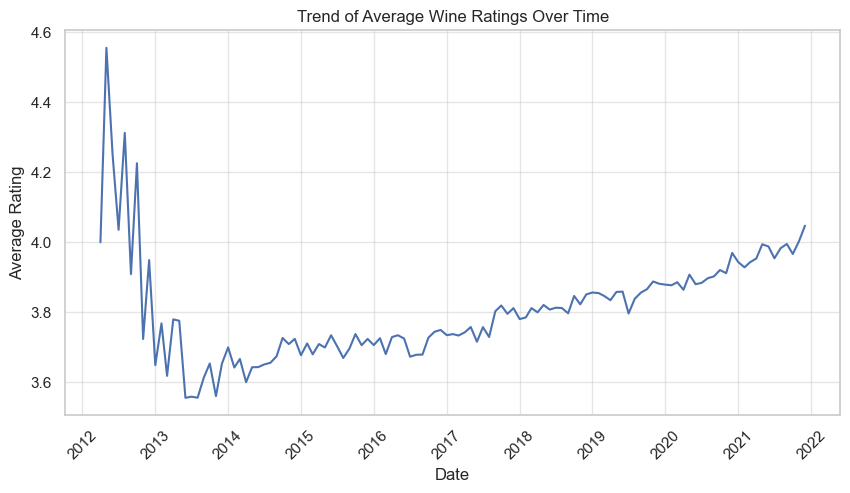

In [16]:

df['Date'] = pd.to_datetime(df['Date'])


monthly_avg_rating = df.groupby(df['Date'].dt.to_period('M'))['Rating'].mean()


sns.lineplot(
    x=monthly_avg_rating.index.to_timestamp(),
    y=monthly_avg_rating.values,
)
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.title("Trend of Average Wine Ratings Over Time")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.show()


# Plotted distribution


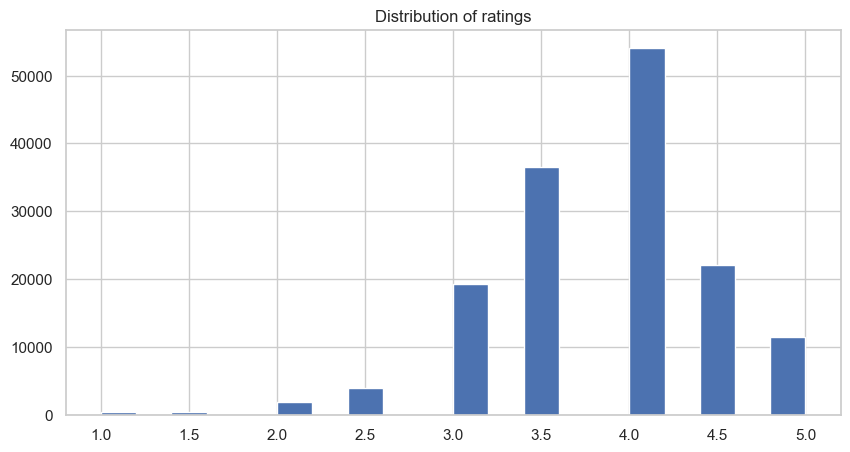

In [17]:


df["Rating"].hist(bins=20)
plt.title("Distribution of ratings")
plt.show()


# Average number of ratings per user

In [18]:
df["UserID"].nunique()



10561

In [19]:
user_counts = df.groupby("UserID")["Rating"].count()
user_counts.describe()

count    10561.000000
mean        14.203200
std          7.043546
min          1.000000
25%         10.000000
50%         12.000000
75%         17.000000
max         67.000000
Name: Rating, dtype: float64

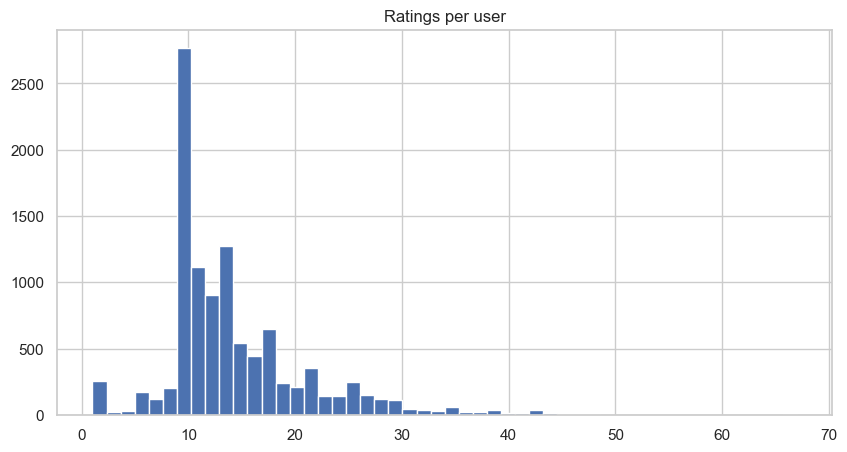

In [20]:
user_counts.hist(bins=50)
plt.title("Ratings per user")
plt.show()


# Cold start items

In [21]:
(user_counts < 3).mean()


np.float64(0.024334816778714137)

In [22]:
df["WineID"].nunique()


1007

In [23]:
wine_counts = df.groupby("WineID")["Rating"].count()
wine_counts.describe()


count    1007.000000
mean      148.957299
std       227.946427
min         1.000000
25%        16.000000
50%        53.000000
75%       164.000000
max      1540.000000
Name: Rating, dtype: float64

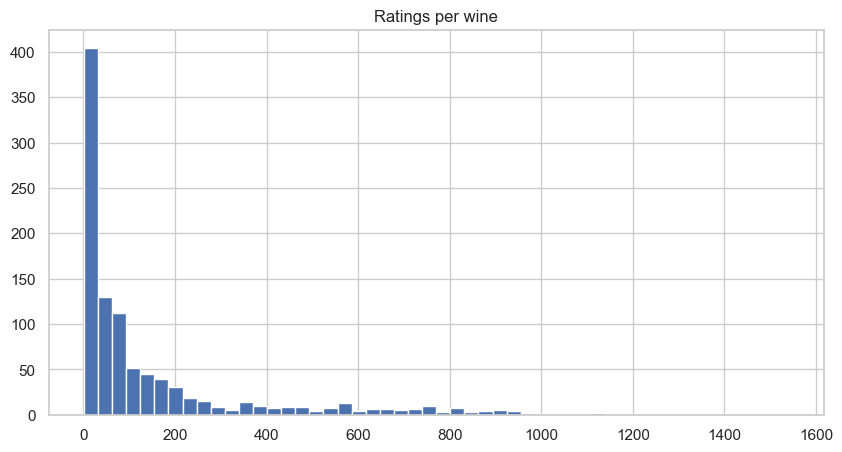

In [29]:
wine_counts.hist(bins=50)
plt.yscale("linear")
plt.title("Ratings per wine")
plt.show()


In [30]:
n_users = df["UserID"].nunique()
n_items = df["WineID"].nunique()

sparsity = len(df) / (n_users * n_items)

print("Sparsity:", sparsity)


Sparsity: 0.014104469170310243


In [31]:
df["Date"].min(), df["Date"].max()


(Timestamp('2012-04-19 20:46:00'), Timestamp('2021-12-31 23:58:52'))

In [44]:
df["Rating"].value_counts(normalize=True, sort=True) * 100


Rating
4.0    36.023333
3.5    24.345333
4.5    14.735333
3.0    12.825333
5.0     7.636667
2.5     2.596667
2.0     1.286667
1.0     0.316667
1.5     0.234000
Name: proportion, dtype: float64

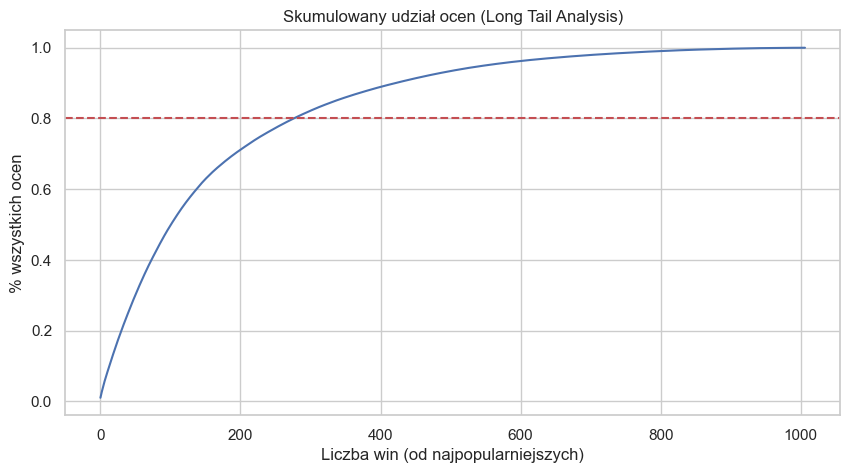

In [45]:
# Analiza Long Tail
wine_counts = df.groupby('WineID').size().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(wine_counts)), wine_counts.cumsum() / wine_counts.sum())
plt.title("Skumulowany udział ocen (Long Tail Analysis)")
plt.xlabel("Liczba win (od najpopularniejszych)")
plt.ylabel("% wszystkich ocen")
plt.axhline(y=0.8, color='r', linestyle='--') # Linia 80% ocen
plt.show()

C:\Users\Filip\AppData\Local\Temp\ipykernel_7360\1735893263.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Month', palette='viridis')


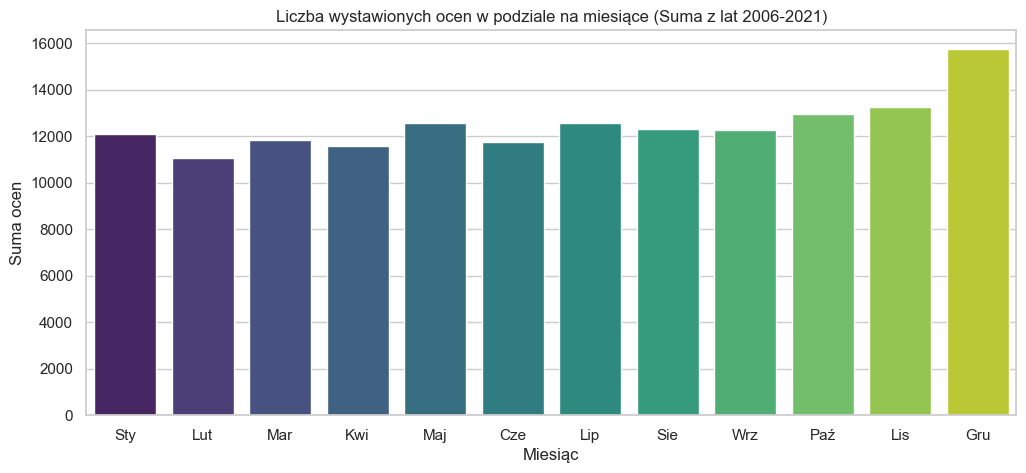

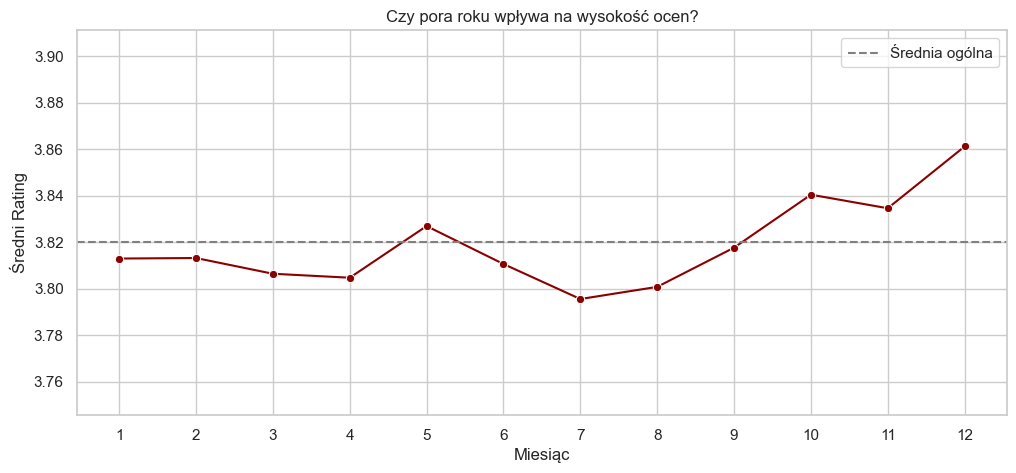

In [46]:
# Przygotowanie danych czasowych
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year

# 1. Liczba ocen w poszczególnych miesiącach (Sezonowość wolumenu)
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Month', palette='viridis')
plt.title('Liczba wystawionych ocen w podziale na miesiące (Suma z lat 2006-2021)')
plt.xlabel('Miesiąc')
plt.ylabel('Suma ocen')
plt.xticks(ticks=np.arange(12), labels=['Sty', 'Lut', 'Mar', 'Kwi', 'Maj', 'Cze', 'Lip', 'Sie', 'Wrz', 'Paź', 'Lis', 'Gru'])
plt.show()

# 2. Średnia ocena w zależności od miesiąca (Sezonowość jakościowa)
monthly_avg = df.groupby('Month')['Rating'].mean()
plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', color='darkred')
plt.axhline(y=df['Rating'].mean(), color='gray', linestyle='--', label='Średnia ogólna')
plt.title('Czy pora roku wpływa na wysokość ocen?')
plt.xlabel('Miesiąc')
plt.ylabel('Średni Rating')
plt.xticks(np.arange(1, 13))
plt.ylim(monthly_avg.min() - 0.05, monthly_avg.max() + 0.05)
plt.legend()
plt.show()

C:\Users\Filip\AppData\Local\Temp\ipykernel_7360\3868757719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='DayOfWeek', y='Rating', order=day_order, palette='coolwarm', errorbar=None)


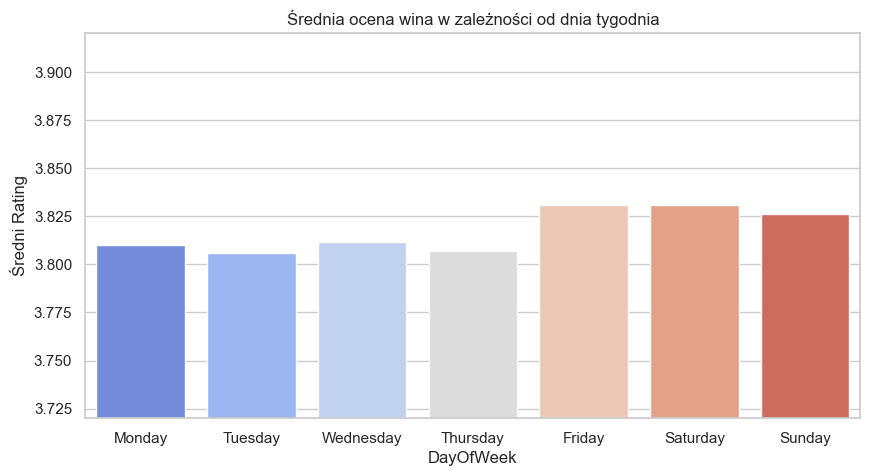

In [47]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='DayOfWeek', y='Rating', order=day_order, palette='coolwarm', errorbar=None)
plt.title('Średnia ocena wina w zależności od dnia tygodnia')
plt.ylim(df['Rating'].mean() - 0.1, df['Rating'].mean() + 0.1)
plt.ylabel('Średni Rating')
plt.show()